In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("rushilprajapati/data-final")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'data-final' dataset.
Path to dataset files: /kaggle/input/data-final
Contents of base_path (/kaggle/input):
['data-final']
Contents of path (/kaggle/input/data-final):
['data']


In [ ]:
import os

# Path to 'data' folder
data_folder_path = os.path.join(path, 'data')

if os.path.exists(data_folder_path):
    contents = os.listdir(data_folder_path)
    print(f"Contents in 'data' folder ({data_folder_path}):")
    display(contents)

    # Deeper check for subdirectories
    for item in contents[:5]: # Check the first 5 items
        item_path = os.path.join(data_folder_path, item)
        if os.path.isdir(item_path):
            print(f"\nSubfolder '{item}' contains: {os.listdir(item_path)[:10]}...")
else:
    print("Data folder not found.")

Contents in 'data' folder (/kaggle/input/data-final/data):


['Blot-Gel',
 'Histopathology',
 'FACS',
 'Macroscopy',
 'Non-scientific',
 'Microscopy']


Subfolder 'Blot-Gel' contains: ['060200 (3).png', '060701.png', '020201 (5).png', '030004 (3).png', '080503.png', '050402 (2).png', '070101 (2).png', '010000 (3).png', '040104 (2).png', '060101 (3).png']...

Subfolder 'Histopathology' contains: ['image_978 (2).png', 'image_2304 (2).png', 'image_339 (2).png', 'image_1796 (2).png', 'image_281.png', 'image_418.png', 'image_1310 (2).png', 'image_2614.png', 'image_1079 (2).png', 'image_2231.png']...

Subfolder 'FACS' contains: ['020201 (5).png', '030004 (3).png', '060105 (3).png', '070101 (2).png', '010000 (3).png', '040104 (2).png', '060101 (3).png', '030008 (3).png', '030015.png', '010003 (3).png']...

Subfolder 'Macroscopy' contains: ['77350309-7fdf-4680-aa75-f70bcfd8de3f.jpg', 'de707955-c27c-45b5-920d-81d107a33c91.jpg', '9acd595c-e8e0-422b-a644-409439ebb01b.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg', 'ISIC_0028872.jpg', '020201 (5).png', 'cedb950b-325a-4c91-8a13-247c260e4163.jpg', '030004 (3).png', '1-3-46-670589-33-1-637380981940983

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Set source and destination paths
source_dir = data_folder_path
base_split_dir = '/content/dataset_split'
train_dir = os.path.join(base_split_dir, 'train')
test_dir = os.path.join(base_split_dir, 'test')

# Create train/test directories
for d in [train_dir, test_dir]:
    if not os.path.exists(d):
        os.makedirs(d)

# Get list of classes (subfolders in 'data')
classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

for cls in classes:
    cls_source_path = os.path.join(source_dir, cls)

    # Create subfolders for each class in train and test
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    # Get list of all image files
    images = [f for f in os.listdir(cls_source_path) if os.path.isfile(os.path.join(cls_source_path, f))]

    if len(images) > 0:
        # Split with 8/2 ratio
        train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

        # Copy files to respective directories
        for img in train_imgs:
            shutil.copy(os.path.join(cls_source_path, img), os.path.join(train_dir, cls, img))
        for img in test_imgs:
            shutil.copy(os.path.join(cls_source_path, img), os.path.join(test_dir, cls, img))

        print(f"Class '{cls}': {len(train_imgs)} train images, {len(test_imgs)} test images.")

print("\nDataset split completed at:", base_split_dir)

Class 'Blot-Gel': 1500 train images, 375 test images.
Class 'Histopathology': 4143 train images, 1036 test images.
Class 'FACS': 856 train images, 214 test images.
Class 'Macroscopy': 3569 train images, 893 test images.
Class 'Non-scientific': 4008 train images, 1002 test images.
Class 'Microscopy': 1207 train images, 302 test images.

Dataset split completed at: /content/dataset_split


In [ ]:
import tensorflow as tf

# Check GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Please enable GPU in Notebook Settings.')
else:
  print(f'Found GPU at: {device_name}')

!nvidia-smi

Found GPU at: /device:GPU:0
Sun Jul  5 22:41:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P0             26W /   70W |     105MiB /  15360MiB |      4%      Default |
|                                         |                        |                  N/A |
+-------------------

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = len(classes)

# Data Generators
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build Model
with tf.device('/GPU:0'):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base model

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='categorical_loss' if NUM_CLASSES == 2 else 'categorical_crossentropy',
                  metrics=['accuracy'])

# Train Model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

Found 15283 images belonging to 6 classes.
Found 3822 images belonging to 6 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 322s 613ms/step - accuracy: 0.9433 - loss: 0.1737 - val_accuracy: 0.9767 - val_loss: 0.0663
Epoch 2/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 246s 514ms/step - accuracy: 0.9779 - loss: 0.0684 - val_accuracy: 0.9796 - val_loss: 0.0567
Epoch 3/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 243s 508ms/step - accuracy: 0.9827 - loss: 0.0525 - val_accuracy: 0.9843 - val_loss: 0.0446
Epoch 4/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 245s 513ms/step - accuracy: 0.9866 - loss: 0.0423 - val_accuracy: 0.9848 - val_loss: 0.0457
Epoch 5/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 247s 518ms/step - accuracy: 0.9880 - loss: 0.0369 - val_accuracy: 0.9869 - val_loss: 0.0373
Epoch 6/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 243s 508ms/step - accuracy: 0.9874 - loss: 0.0373 - val_accuracy: 0.9864 - val_loss: 0.0377
Epoch 7/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 246s 514ms/step - accuracy: 0.98

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(validation_generator)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

# Summary of parameters
model.summary()

120/120 ━━━━━━━━━━━━━━━━━━━━ 18s 146ms/step - accuracy: 0.9877 - loss: 0.0372
Final Validation Loss: 0.0372
Final Validation Accuracy: 0.9877


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,829,332 (29.87 MB)

 Trainable params: 263,942 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 527,886 (2.01 MB)

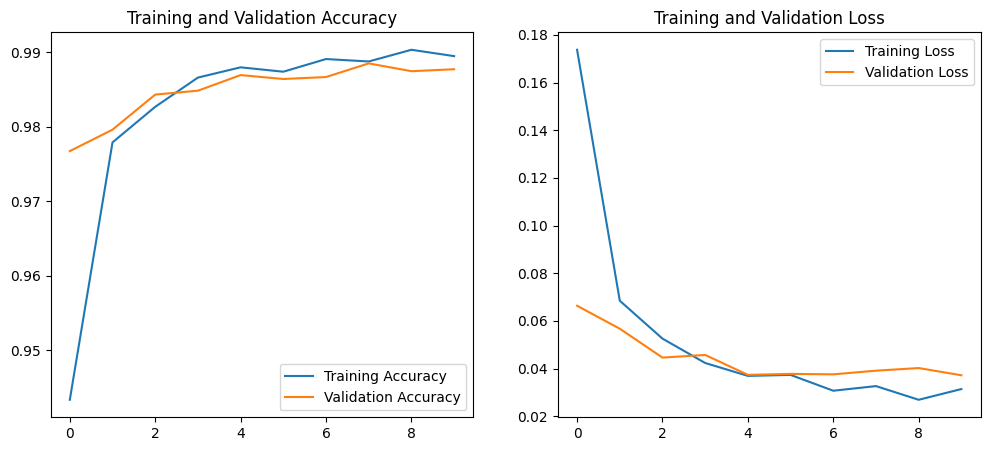

In [ ]:
import matplotlib.pyplot as plt

# Plot Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()